# scikit-learn — task-indexed cheatsheet


Most of sklearn boils down to one workflow:

1. Define a model (or a `Pipeline` of preprocessing + model).
2. Fit it on `(X_train, y_train)`.
3. Predict / score on new data.

The bits that bite people: **the right CV scheme**, **scoring-string sign conventions**, **predict vs predict_proba**, and **leakage from preprocessing fit on the wrong data**. Each gets its own section below.


---
## Setup

Run this once.


### Setup — run me first


In [1]:
import numpy as np
import pandas as pd
from sklearn.datasets import make_classification, make_regression

# Reproducible synthetic datasets used by every entry.
rng = np.random.default_rng(0)
X_clf, y_clf = make_classification(n_samples=400, n_features=6, n_informative=4, random_state=0)
X_clf = pd.DataFrame(X_clf, columns=[f'f{i}' for i in range(6)])
X_clf_tr, X_clf_va, y_clf_tr, y_clf_va = X_clf[:300], X_clf[300:], y_clf[:300], y_clf[300:]

X_reg, y_reg = make_regression(n_samples=400, n_features=4, noise=5, random_state=0)
X_reg = pd.DataFrame(X_reg, columns=[f'f{i}' for i in range(4)])
X_reg_tr, X_reg_va, y_reg_tr, y_reg_va = X_reg[:300], X_reg[300:], y_reg[:300], y_reg[300:]

---
## 1. Pipelines and preprocessing

**Always** wrap preprocessing inside a `Pipeline`. This is the only way `cross_val_score` knows to refit the scaler on each fold's training data — otherwise you leak val statistics into train.


### How do I combine a scaler with a model?

`Pipeline([('sc', StandardScaler()), ('m', LogisticRegression())])`. Treat the pipeline as a model — `.fit()`, `.predict()`, `.predict_proba()` all work as usual.


In [2]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

pipe = Pipeline([('sc', StandardScaler()), ('m', LogisticRegression())])
pipe.fit(X_clf_tr, y_clf_tr)
print(f'val acc: {pipe.score(X_clf_va, y_clf_va):.3f}')

val acc: 0.720


*Why pipeline rather than scaling manually*: `pipe.fit()` fits the scaler on `X_clf_tr` only; in CV, it refits on each fold's train slice. Manual scaling fits once on all data → leakage. *Common mistake*: scaling the full `X` first, then doing CV — the scaler has already seen val data.


### How do I apply different preprocessing to different columns?

`ColumnTransformer`. Lets you scale numerics, one-hot encode categoricals, etc., in parallel.


In [3]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

X_mixed = X_clf.copy()
X_mixed['cat'] = rng.choice(['a', 'b', 'c'], size=len(X_mixed))

ct = ColumnTransformer([
    ('numeric', StandardScaler(), [c for c in X_mixed.columns if c != 'cat']),
    ('cat',     OneHotEncoder(),  ['cat']),
])
X_transformed = ct.fit_transform(X_mixed)
print(X_transformed.shape)

(400, 9)


*When to use*: any time your X has heterogeneous columns. *Common mistake*: passing column names that don't exist — silent drop in older sklearn, error in newer versions.


---
## 2. Splits and cross-validation

**The single most important sklearn decision: which split scheme.** For time series, only `TimeSeriesSplit` is correct. For everything else, `KFold` is fine. `train_test_split` is the convenience for one-off splits.


### How do I do a simple train/test split?

`train_test_split(X, y, test_size=0.3, random_state=0)`. Use `stratify=y` for imbalanced classification.


In [4]:
from sklearn.model_selection import train_test_split

X_tr, X_te, y_tr, y_te = train_test_split(
    X_clf, y_clf, test_size=0.3, random_state=0, stratify=y_clf,
)
print(f'train: {len(X_tr)}, test: {len(X_te)}')

train: 280, test: 120


*Why stratify*: keeps class proportions identical in train and test, important for imbalanced data. *Common mistake*: using `train_test_split` (which shuffles) on **time-series data** — leaks the future into the past.


### How do I do CV on time-series data?

`TimeSeriesSplit(n_splits=5)`. Folds are chronological: train < val by construction.


In [5]:
from sklearn.model_selection import TimeSeriesSplit

tscv = TimeSeriesSplit(n_splits=5)
for k, (tr_idx, va_idx) in enumerate(tscv.split(X_clf)):
    print(f'fold {k}: train rows {tr_idx[0]}..{tr_idx[-1]}, val {va_idx[0]}..{va_idx[-1]}')

fold 0: train rows 0..69, val 70..135
fold 1: train rows 0..135, val 136..201
fold 2: train rows 0..201, val 202..267
fold 3: train rows 0..267, val 268..333
fold 4: train rows 0..333, val 334..399


*Why TimeSeriesSplit*: every fold's val rows come strictly after train rows. The standard `KFold(shuffle=True)` interleaves train and val in time, leaking the future. *Common mistake*: using TimeSeriesSplit but not actually sorting your X chronologically first — the split is by row position, not by index value.


### How do I score a model via CV in one line?

`cross_val_score(model, X, y, cv=..., scoring='...')` returns an array of fold scores.


In [6]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(pipe, X_clf, y_clf, cv=TimeSeriesSplit(5), scoring='roc_auc')
print(f'fold scores: {scores.round(3)}')
print(f'mean ± std:  {scores.mean():.3f} ± {scores.std():.3f}')

fold scores: [0.824 0.727 0.815 0.774 0.755]
mean ± std:  0.779 ± 0.036


*Common mistake*: passing `cv=5` (an int) — sklearn defaults to `KFold(5)` for regression, `StratifiedKFold(5)` for classification. **Both shuffle. Both wrong for time series.** Always pass a `TimeSeriesSplit` instance for sequential data.


### How do I get multiple scoring metrics in one CV pass?

`cross_validate(model, X, y, cv=..., scoring=['accuracy', 'roc_auc', 'neg_log_loss'])`. Returns a dict.


In [7]:
from sklearn.model_selection import cross_validate

result = cross_validate(
    pipe, X_clf, y_clf,
    cv=TimeSeriesSplit(5),
    scoring=['accuracy', 'roc_auc', 'neg_log_loss'],
    return_train_score=False,
)
for metric in ['accuracy', 'roc_auc', 'neg_log_loss']:
    arr = result[f'test_{metric}']
    print(f'{metric:>14}: {arr.mean():.4f} ± {arr.std():.4f}')

      accuracy: 0.7030 ± 0.0435
       roc_auc: 0.7789 ± 0.0364
  neg_log_loss: -0.5936 ± 0.0569


*Why this over multiple cross_val_score calls*: the model gets fit once per fold instead of once per (fold × metric). *Common mistake*: confusing `test_*` (the val score) with `train_*` (the in-sample score) — sklearn's naming is historical and confusing.


---
## 3. Scoring strings — sign conventions and gotchas

Sklearn scoring strings follow one rule: **higher is better**. Metrics that are naturally lower-is-better (loss, error) are negated and prefixed with `neg_`.


### Why is log_loss called 'neg_log_loss'?

Sklearn negates lower-is-better metrics so all scoring strings are higher-is-better. `'neg_log_loss'` returns the negative of log-loss; remember to negate again to interpret.


In [8]:
from sklearn.metrics import log_loss

# Direct log_loss is positive (lower = better).
proba = pipe.predict_proba(X_clf_va)
print(f'direct log_loss:           {log_loss(y_clf_va, proba):.4f}')

# Via cross_val_score it's negative (higher = better, sklearn convention).
neg = cross_val_score(pipe, X_clf, y_clf, cv=TimeSeriesSplit(3), scoring='neg_log_loss').mean()
print(f'neg_log_loss (sklearn):    {neg:.4f}')
print(f'sign-flipped to interpret: {-neg:.4f}')

direct log_loss:           0.6180


neg_log_loss (sklearn):    -0.5819
sign-flipped to interpret: 0.5819


*The full list*: `neg_log_loss`, `neg_mean_squared_error`, `neg_mean_absolute_error`, `neg_brier_score`, etc. *Common mistake*: forgetting to flip the sign when reporting → printing a 'log loss of -0.5' that's actually 0.5.


### What scoring string for AUC, accuracy, F1?

`'roc_auc'`, `'accuracy'`, `'f1'` — all higher-is-better, no `neg_` prefix.


In [9]:
metrics = ['roc_auc', 'accuracy', 'f1', 'precision', 'recall']
for m in metrics:
    s = cross_val_score(pipe, X_clf, y_clf, cv=TimeSeriesSplit(3), scoring=m).mean()
    print(f'{m:>10}: {s:.4f}')

   roc_auc: 0.7780


  accuracy: 0.7167
        f1: 0.7212
 precision: 0.7075


    recall: 0.7409


*For multi-class*: append `_macro`, `_micro`, or `_weighted` (e.g. `'f1_macro'`). *Common mistake*: passing `'auc'` instead of `'roc_auc'` — wrong string, sklearn raises.


### What scoring string for regression?

`'neg_mean_absolute_error'`, `'neg_mean_squared_error'`, `'neg_root_mean_squared_error'`, `'r2'`. All except r2 are negated.


In [10]:
from sklearn.linear_model import Ridge
ridge = Ridge()
metrics = ['neg_mean_absolute_error', 'neg_mean_squared_error', 'r2']
for m in metrics:
    s = cross_val_score(ridge, X_reg, y_reg, cv=TimeSeriesSplit(3), scoring=m).mean()
    print(f'{m:>30}: {s:.4f}')

       neg_mean_absolute_error: -4.1352


        neg_mean_squared_error: -26.1856
                            r2: 0.9975


*Common mistake*: comparing `'neg_mean_squared_error'` across two datasets with different y-scales — RMSE-style metrics are scale-dependent, MAPE/r² aren't.


---
## 4. predict vs predict_proba vs decision_function

Three different outputs for classifiers; choosing the right one depends on what you need.


### How do I get hard class labels?

`model.predict(X)`. Returns the predicted class for each row.


In [11]:
y_hat = pipe.predict(X_clf_va)
print(y_hat[:10])

[1 0 0 1 1 1 1 0 0 1]


*When to use*: when downstream code expects integer labels (e.g. confusion matrix, accuracy).


### How do I get class probabilities?

`model.predict_proba(X)`. Returns shape `(n, n_classes)`. For binary, use column 1 for the positive class probability.


In [12]:
proba = pipe.predict_proba(X_clf_va)[:, 1]
print(proba[:5].round(3))

[0.796 0.118 0.428 0.886 0.653]


*When to use*: any time you want a confidence score, AUC, or threshold-tuning. *Common mistake*: forgetting `[:, 1]` and trying to compute log_loss on a 2D array — works in some cases, breaks in others.


### What's `decision_function`?

Raw, uncalibrated scores. For SVMs, the signed distance to the hyperplane; for linear models, the logit before sigmoid.


In [13]:
from sklearn.svm import LinearSVC
svc = LinearSVC().fit(X_clf_tr, y_clf_tr)
scores = svc.decision_function(X_clf_va)
print(scores[:5].round(3))

[ 0.553 -0.807 -0.143  0.792  0.211]


*When to use*: AUC for models that don't output probabilities (e.g. LinearSVC). *Common mistake*: treating `decision_function` outputs as probabilities — they're unbounded; you need calibration first.


---
## 5. Common models — when to reach for which

The five models that cover 80% of tabular ML problems. Each has reasonable defaults; you usually don't need to tune unless the model is genuinely the bottleneck.


### Linear / logistic regression — the default starting point.

`LogisticRegression()` for classification, `Ridge()` (L2) or `Lasso()` (L1) for regression. Fast, calibrated, interpretable.


In [14]:
from sklearn.linear_model import LogisticRegression, Ridge, Lasso

lr = LogisticRegression(C=1.0, max_iter=500).fit(X_clf_tr, y_clf_tr)
ridge = Ridge(alpha=1.0).fit(X_reg_tr, y_reg_tr)
print(f'LR val acc:    {lr.score(X_clf_va, y_clf_va):.3f}')
print(f'Ridge val r2:  {ridge.score(X_reg_va, y_reg_va):.3f}')

LR val acc:    0.720
Ridge val r2:  0.997


*When to use*: always try first. If linear beats your fancy model, the problem is linear and the fancy model was overfit. *Common mistake*: forgetting to scale inputs — linear models converge faster and behave better on standardised data.


### Random forest — robust default for non-linear tabular data.

`RandomForestClassifier(n_estimators=200, max_depth=10)`. Handles non-linear interactions natively.


In [15]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=200, max_depth=10, n_jobs=-1, random_state=0)
rf.fit(X_clf_tr, y_clf_tr)
print(f'RF val acc: {rf.score(X_clf_va, y_clf_va):.3f}')

RF val acc: 0.850


*When to use*: when linear isn't enough and you want zero hyperparameter tuning. *Common mistake*: not setting `max_depth` — unbounded trees overfit on noisy data; cap at 8-15 unless the data is huge.


### Gradient boosting — usually the strongest tabular model.

`GradientBoostingClassifier`/`Regressor` from sklearn, or LightGBM/XGBoost for speed. Sequential trees, each fitting the previous's residuals.


In [16]:
from sklearn.ensemble import GradientBoostingClassifier

gbm = GradientBoostingClassifier(n_estimators=200, max_depth=3, learning_rate=0.1, random_state=0)
gbm.fit(X_clf_tr, y_clf_tr)
print(f'GBM val acc: {gbm.score(X_clf_va, y_clf_va):.3f}')

GBM val acc: 0.840


*When to use*: tabular data where you have time to tune. LightGBM (next cheatsheet) is the production-grade alternative — same idea, much faster. *Common mistake*: deep trees + high learning rate → overfit. Standard recipe: `max_depth=3-6, learning_rate=0.05-0.1, n_estimators=200-500`.


### Dummy classifier / regressor — the baselines.

`DummyClassifier(strategy='most_frequent')` predicts the majority class. Use it as a benchmark.


In [17]:
from sklearn.dummy import DummyClassifier, DummyRegressor

dummy_c = DummyClassifier(strategy='most_frequent').fit(X_clf_tr, y_clf_tr)
dummy_r = DummyRegressor(strategy='mean').fit(X_reg_tr, y_reg_tr)
print(f'majority baseline acc: {dummy_c.score(X_clf_va, y_clf_va):.3f}')
print(f'mean    baseline r2:   {dummy_r.score(X_reg_va, y_reg_va):.3f}')

majority baseline acc: 0.470
mean    baseline r2:   -0.003


*When to use*: every project. If your real model can't beat this, you have no edge. *Strategies*: `'most_frequent'` (majority), `'stratified'` (random with class probs), `'uniform'` (random), `'constant'` (fixed value).


---
## 6. Calibration and saving models

Calibration: turning raw scores into actual probabilities. Persistence: saving the trained model so you don't retrain on every restart.


### How do I calibrate an already-trained classifier (sklearn ≥ 1.6)?

Wrap with `FrozenEstimator` and use `CalibratedClassifierCV(... cv=5)`. (The old `cv='prefit'` was removed in 1.6.)


In [18]:
from sklearn.calibration import CalibratedClassifierCV
from sklearn.frozen import FrozenEstimator

# Pretend rf is already trained on X_clf_tr.
cal = CalibratedClassifierCV(FrozenEstimator(rf), method='isotonic', cv=5)
cal.fit(X_clf_va, y_clf_va)             # calibrate on val
proba_cal = cal.predict_proba(X_clf_va)[:, 1]
print(f'calibrated proba range: [{proba_cal.min():.3f}, {proba_cal.max():.3f}]')

calibrated proba range: [0.000, 1.000]


*Why isotonic vs Platt (sigmoid)*: isotonic is non-parametric, better for ≥1000 calibration samples; Platt fits a sigmoid, better for small samples. *Common mistake*: calibrating on the same data the base model was trained on — overfit calibrator. Use a held-out set.


### How do I save and load a model?

`joblib.dump(model, path)` and `joblib.load(path)`. Better than pickle for numpy-heavy objects.


In [19]:
import joblib, tempfile, os

path = os.path.join(tempfile.gettempdir(), 'demo_model.joblib')
joblib.dump(pipe, path)
restored = joblib.load(path)
print(f'restored.score: {restored.score(X_clf_va, y_clf_va):.3f}')

restored.score: 0.720


*Why joblib over pickle*: faster for numpy arrays, smaller files. *Common mistake*: saving the model alone, then losing the feature names. Save a dict: `{'model': pipe, 'feature_names': X_clf_tr.columns.tolist()}`.


---
## 7. Metrics — what to import and what to feed it

The five most-used metric functions. Pay attention to whether they want hard predictions (0/1) or probabilities — getting it wrong is the most common metric bug.


### How do I compute classification metrics?

Hard predictions: `accuracy_score`, `f1_score`, `precision_score`, `recall_score`, `confusion_matrix`. Probabilities: `roc_auc_score`, `log_loss`, `brier_score_loss`.


In [20]:
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score, log_loss,
    confusion_matrix, classification_report,
)

y_pred = pipe.predict(X_clf_va)
y_proba = pipe.predict_proba(X_clf_va)[:, 1]

print(f'accuracy:  {accuracy_score(y_clf_va, y_pred):.4f}')
print(f'f1:        {f1_score(y_clf_va, y_pred):.4f}')
print(f'roc_auc:   {roc_auc_score(y_clf_va, y_proba):.4f}')
print(f'log_loss:  {log_loss(y_clf_va, np.clip(y_proba, 1e-6, 1 - 1e-6)):.4f}')
print('\nconfusion matrix:')
print(confusion_matrix(y_clf_va, y_pred))

accuracy:  0.7200
f1:        0.7143
roc_auc:   0.7499
log_loss:  0.6180

confusion matrix:
[[37 16]
 [12 35]]


*Common mistake*: passing hard 0/1 to `log_loss` — gives huge values from clipping eps. Always feed probabilities, and clip them yourself if you want a known eps.


### How do I compute regression metrics?

`mean_absolute_error`, `mean_squared_error` (`squared=False` for RMSE in older sklearn; `root_mean_squared_error` in newer), `r2_score`.


In [21]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

y_pred = ridge.predict(X_reg_va)
print(f'MAE:  {mean_absolute_error(y_reg_va, y_pred):.3f}')
print(f'MSE:  {mean_squared_error(y_reg_va, y_pred):.3f}')
print(f'RMSE: {np.sqrt(mean_squared_error(y_reg_va, y_pred)):.3f}')
print(f'r2:   {r2_score(y_reg_va, y_pred):.3f}')

MAE:  4.381
MSE:  28.711
RMSE: 5.358
r2:   0.997


*When to use which*: MAE for robustness to outliers; MSE/RMSE for penalising large errors more; r2 for scale-free interpretation.


### How do I compute feature importance for any model?

`from sklearn.inspection import permutation_importance`. Model-agnostic, works on any fitted estimator.


In [22]:
from sklearn.inspection import permutation_importance

perm = permutation_importance(pipe, X_clf_va, y_clf_va, n_repeats=5, random_state=0)
imp = pd.Series(perm.importances_mean, index=X_clf_va.columns).sort_values(ascending=False)
print(imp.round(4))

f5    0.158
f4    0.090
f1    0.042
f2    0.034
f3    0.020
f0    0.006
dtype: float64


*When to use*: any model where you want a model-agnostic importance ranking. *Why on val (not train)*: train importance reflects what the model fit; val importance reflects what the model uses to generalise.


---
## 8. More: chaining, imbalance, diagnostics, missing data

Six idioms that fill predictable gaps in the basic supervised-learning loop.


### How do I copy an unfitted estimator's structure?

`from sklearn.base import clone`. Returns a fresh, unfitted clone with the same hyperparameters.


In [23]:
from sklearn.base import clone
from sklearn.ensemble import RandomForestClassifier

template = RandomForestClassifier(n_estimators=200, max_depth=5, random_state=0)

# In a CV loop you want a fresh instance per fold — clone() gives you that.
for fold in range(3):
    m = clone(template)
    # m.fit(X_tr, y_tr) ...
    print(f'fold {fold}: cloned, ready to fit')

fold 0: cloned, ready to fit
fold 1: cloned, ready to fit
fold 2: cloned, ready to fit


*Why clone over deepcopy*: clone preserves only the hyperparameters, not any fitted state — exactly what you want for CV / ablation. *Common mistake*: re-using the same fitted model across CV folds. The 'final' fit is whatever fold ran last; the comparison is corrupted.


### How do I write a Pipeline more concisely?

`make_pipeline(*steps)` and `make_column_transformer(*tuples)` — names are auto-generated.


In [24]:
from sklearn.pipeline import make_pipeline, Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.compose import make_column_transformer
from sklearn.preprocessing import OneHotEncoder

# Verbose form.
verbose = Pipeline([('scaler', StandardScaler()), ('clf', LogisticRegression())])

# Concise form — same thing, names inferred from class.
concise = make_pipeline(StandardScaler(), LogisticRegression())

# Same idea for ColumnTransformer.
ct = make_column_transformer(
    (StandardScaler(), ['f0', 'f1']),
    (OneHotEncoder(),  ['cat']),
)

*Why concise form*: less typing for simple chains. *Common mistake*: needing to reference a step by name in `set_params(...)` — the auto-generated name is lowercased class name (`logisticregression`), which is awkward. Use the verbose form when you need clean step names.


### How do I handle imbalanced classes?

`class_weight='balanced'` (model param) or `sample_weight=` (fit param). Both rebalance the loss.


In [25]:
import numpy as np
from sklearn.datasets import make_classification
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score

# Imbalanced: 90/10 split.
X, y = make_classification(n_samples=1000, weights=[0.9, 0.1], random_state=0)

unweighted = LogisticRegression(max_iter=500).fit(X, y)
balanced = LogisticRegression(max_iter=500, class_weight='balanced').fit(X, y)

print(f'unweighted F1: {f1_score(y, unweighted.predict(X)):.3f}')
print(f'balanced F1:   {f1_score(y, balanced.predict(X)):.3f}')

unweighted F1: 0.876
balanced F1:   0.841


*Why class_weight='balanced'*: cheaper than oversampling/SMOTE; works with any sklearn classifier. *Common mistake*: stratifying CV folds but forgetting `class_weight` — the model still ignores the minority class within each fold.


### How do I see how a hyperparameter affects performance?

`validation_curve` for one parameter, varied across a range. `learning_curve` for performance vs training-set size.


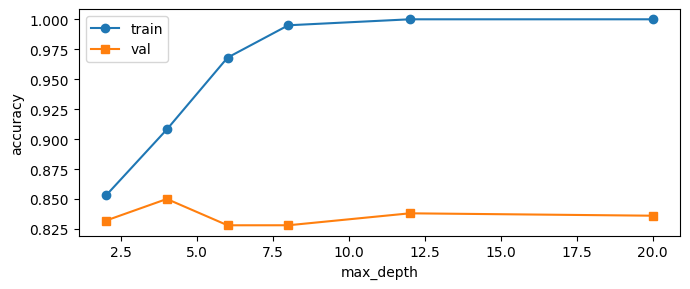

In [26]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import validation_curve

X, y = make_classification(n_samples=500, random_state=0)

depths = [2, 4, 6, 8, 12, 20]
train_scores, val_scores = validation_curve(
    RandomForestClassifier(n_estimators=100, random_state=0),
    X, y, param_name='max_depth', param_range=depths, cv=3, scoring='accuracy',
)

fig, ax = plt.subplots(figsize=(7, 3))
ax.plot(depths, train_scores.mean(axis=1), 'o-', label='train')
ax.plot(depths, val_scores.mean(axis=1), 's-', label='val')
ax.set_xlabel('max_depth'); ax.set_ylabel('accuracy'); ax.legend()
plt.tight_layout(); plt.show()

*When to use*: diagnosing under/overfit at a glance. Train-val gap widens at high capacity → overfitting. *Common mistake*: small `cv` like `cv=2` makes the curves jagged; use `cv=5` minimum.


### How do I impute missing values?

`SimpleImputer` for fixed strategies (mean / median / most_frequent / constant). `IterativeImputer` for model-based imputation (multivariate).


In [27]:
import numpy as np
import pandas as pd
from sklearn.impute import SimpleImputer
# Need to enable the experimental flag for IterativeImputer.
from sklearn.experimental import enable_iterative_imputer  # noqa: F401
from sklearn.impute import IterativeImputer

X = pd.DataFrame({
    'a': [1.0, 2.0, np.nan, 4.0, 5.0],
    'b': [10.0, np.nan, 30.0, 40.0, 50.0],
})

# Simple median imputation.
median = SimpleImputer(strategy='median').fit_transform(X)
print('median:'); print(median)

# Iterative: each missing value is imputed using the *other* features.
iterative = IterativeImputer(random_state=0).fit_transform(X)
print('iterative:'); print(iterative.round(3))

median:
[[ 1. 10.]
 [ 2. 35.]
 [ 3. 30.]
 [ 4. 40.]
 [ 5. 50.]]
iterative:
[[ 1. 10.]
 [ 2. 20.]
 [ 3. 30.]
 [ 4. 40.]
 [ 5. 50.]]


*Why iterative over simple*: when features correlate, the iterative imputer uses that correlation; simple median ignores it. *Common mistake*: imputing across train+test together — leakage; always wrap in a `Pipeline` with the rest of preprocessing.


### How do I rank features by importance and pick the top-K?

`SelectKBest` for univariate; `RFE` for recursive elimination using a model.


In [28]:
from sklearn.datasets import make_classification
from sklearn.feature_selection import SelectKBest, f_classif, RFE
from sklearn.ensemble import RandomForestClassifier

X, y = make_classification(n_samples=400, n_features=8, n_informative=3, random_state=0)

# Univariate: rank each feature against y independently.
sk = SelectKBest(score_func=f_classif, k=3).fit(X, y)
print(f'univariate top-3 indices: {sk.get_support(indices=True)}')

# RFE: fit a model, drop weakest, refit, drop again — recursive.
rfe = RFE(RandomForestClassifier(n_estimators=50, random_state=0), n_features_to_select=3).fit(X, y)
print(f'RFE top-3 indices:        {rfe.get_support(indices=True)}')

univariate top-3 indices: [2 3 7]


RFE top-3 indices:        [2 6 7]


*When to use which*: SelectKBest is fast and ignores feature interactions; RFE is slower and respects interactions. *Common mistake*: using SelectKBest with f_classif on highly-correlated features — they all score similarly so you pick redundantly.
